<a href="https://colab.research.google.com/github/PrishitaM/Unsupervised-full-customer-segmentation-ml/blob/main/Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AllLife Bank – Credit Card Customer Segmentation**

## **Exploratory Data Analysis**

Importing necessary libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from sklearn.cluster import AgglomerativeClustering

In [4]:
data = pd.read_excel("Credit Card Customer Data.xlsx")

In [ ]:
data.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [ ]:
data.tail()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0
659,660,80150,167000,9,0,12,2


In [ ]:
data.shape

(660, 7)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Sl_No,660.0,330.500000,190.669872,1.0,165.75,330.5,495.25,660.0
Customer Key,660.0,55141.443939,25627.772200,11265.0,33825.25,53874.5,77202.50,99843.0
Avg_Credit_Limit,660.0,34574.242424,37625.487804,3000.0,10000.00,18000.0,48000.00,200000.0
Total_Credit_Cards,660.0,4.706061,2.167835,1.0,3.00,5.0,6.00,10.0
Total_visits_bank,660.0,2.403030,1.631813,0.0,1.00,2.0,4.00,5.0
Total_visits_online,660.0,2.606061,2.935724,0.0,1.00,2.0,4.00,15.0
Total_calls_made,660.0,3.583333,2.865317,0.0,1.00,3.0,5.00,10.0


In [5]:
df = data.copy()
df.drop(["Sl_No", "Customer Key"], axis=1, inplace=True)

In [6]:
num_col = df.columns.tolist()
num_col

['Avg_Credit_Limit',
 'Total_Credit_Cards',
 'Total_visits_bank',
 'Total_visits_online',
 'Total_calls_made']

Univariate Analysis

Distribution of Avg_Credit_Limit

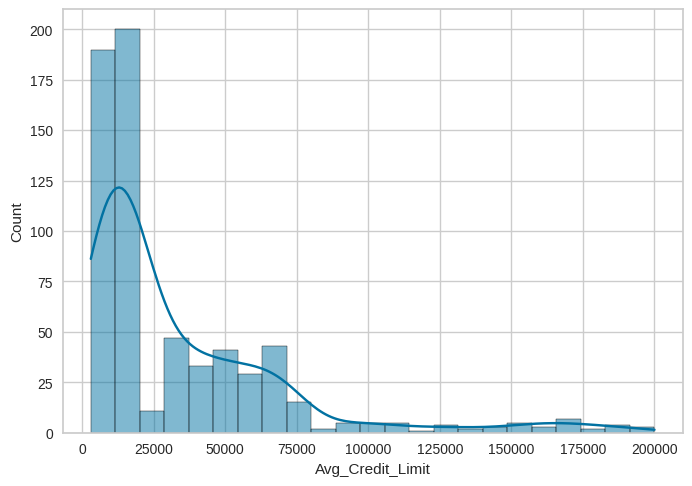

In [ ]:
sns.histplot(data=df, x="Avg_Credit_Limit", kde=True)
plt.show()

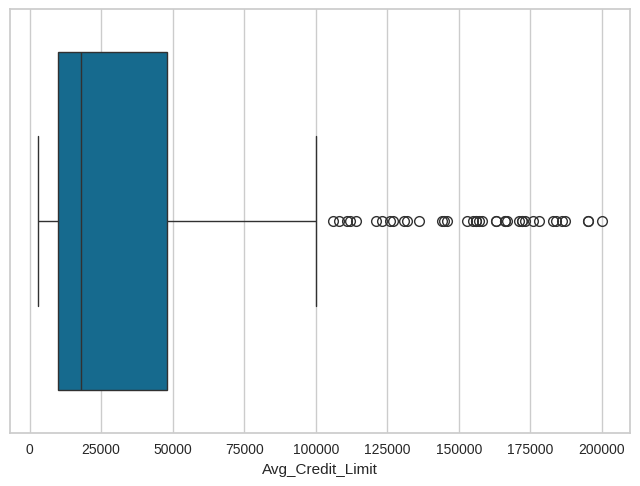

In [ ]:
sns.boxplot(data=df, x="Avg_Credit_Limit")
plt.show()

Total_Credit_Cards

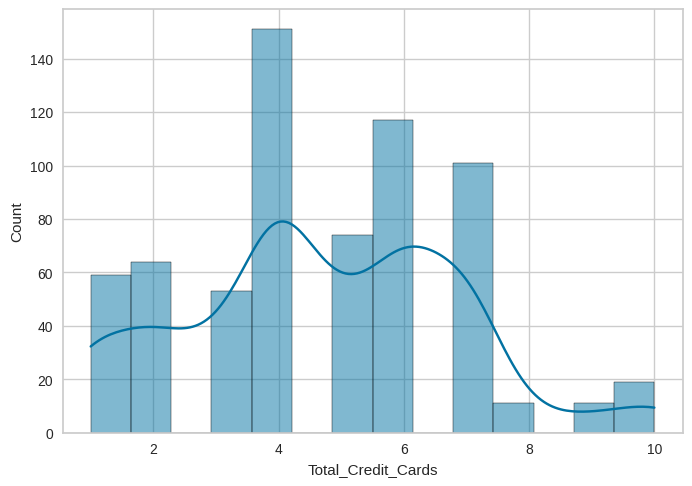

In [ ]:
sns.histplot(data=df, x="Total_Credit_Cards", kde=True)
plt.show()

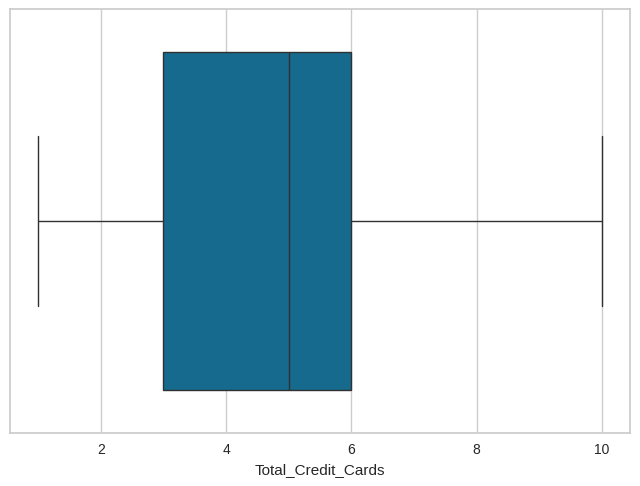

In [ ]:
sns.boxplot(data=df, x="Total_Credit_Cards")
plt.show()

Total_visits_bank

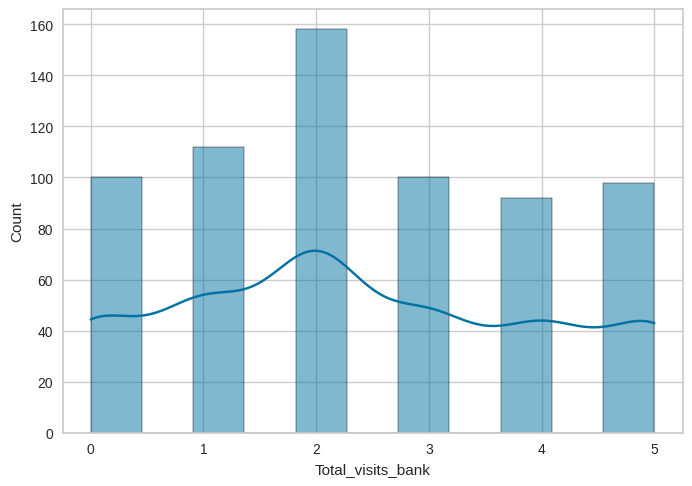

In [ ]:
sns.histplot(data=df, x="Total_visits_bank", kde=True)
plt.show()

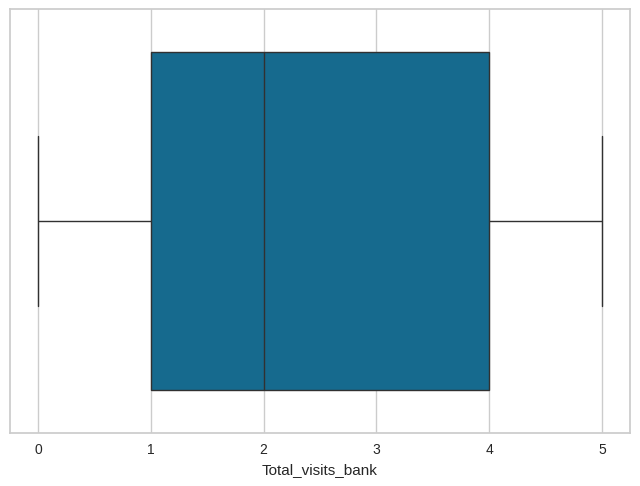

In [ ]:
sns.boxplot(data=df, x="Total_visits_bank")
plt.show()

Total_visits_online

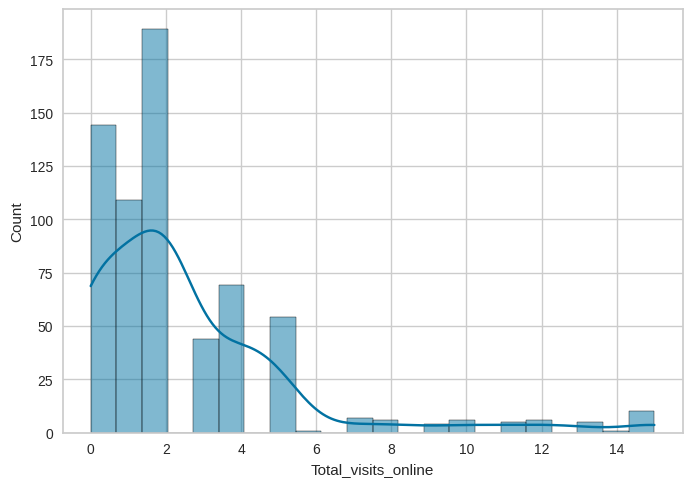

In [ ]:
sns.histplot(data=df, x="Total_visits_online", kde=True)
plt.show()

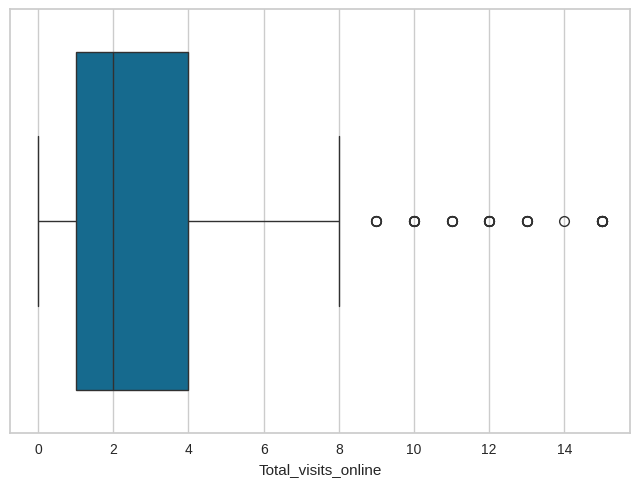

In [ ]:
sns.boxplot(data=df, x="Total_visits_online")
plt.show()

Total_calls_made

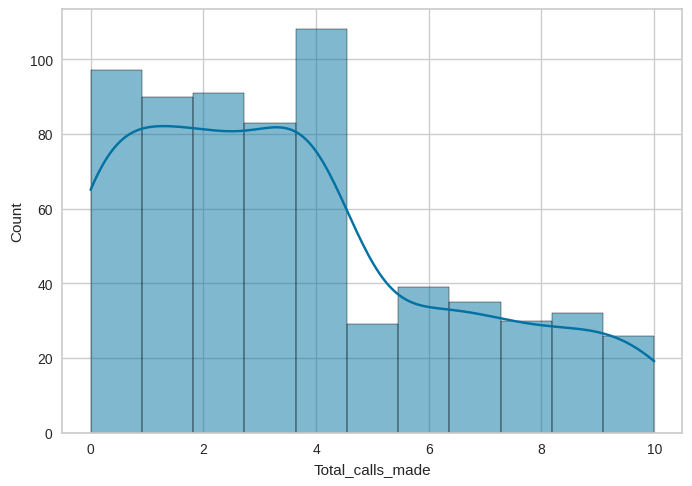

In [ ]:
sns.histplot(data=df, x="Total_calls_made", kde=True)
plt.show()

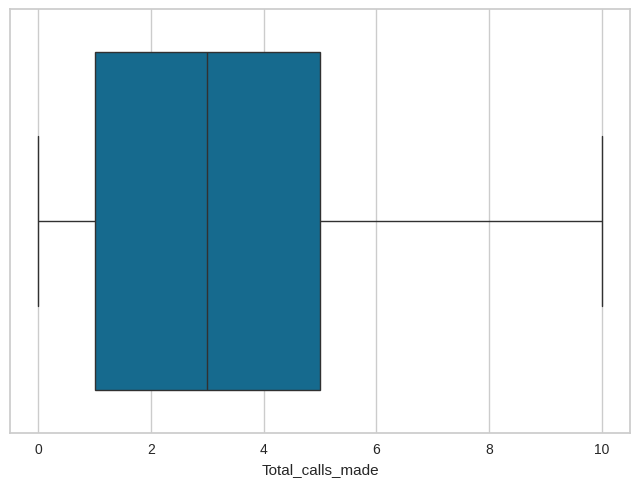

In [ ]:
sns.boxplot(data=df, x="Total_calls_made")
plt.show()

Bivariate Analysis

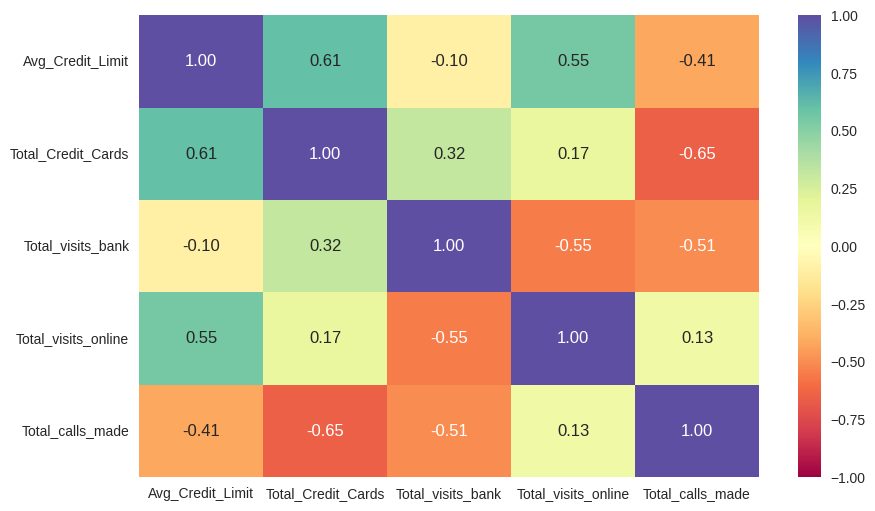

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

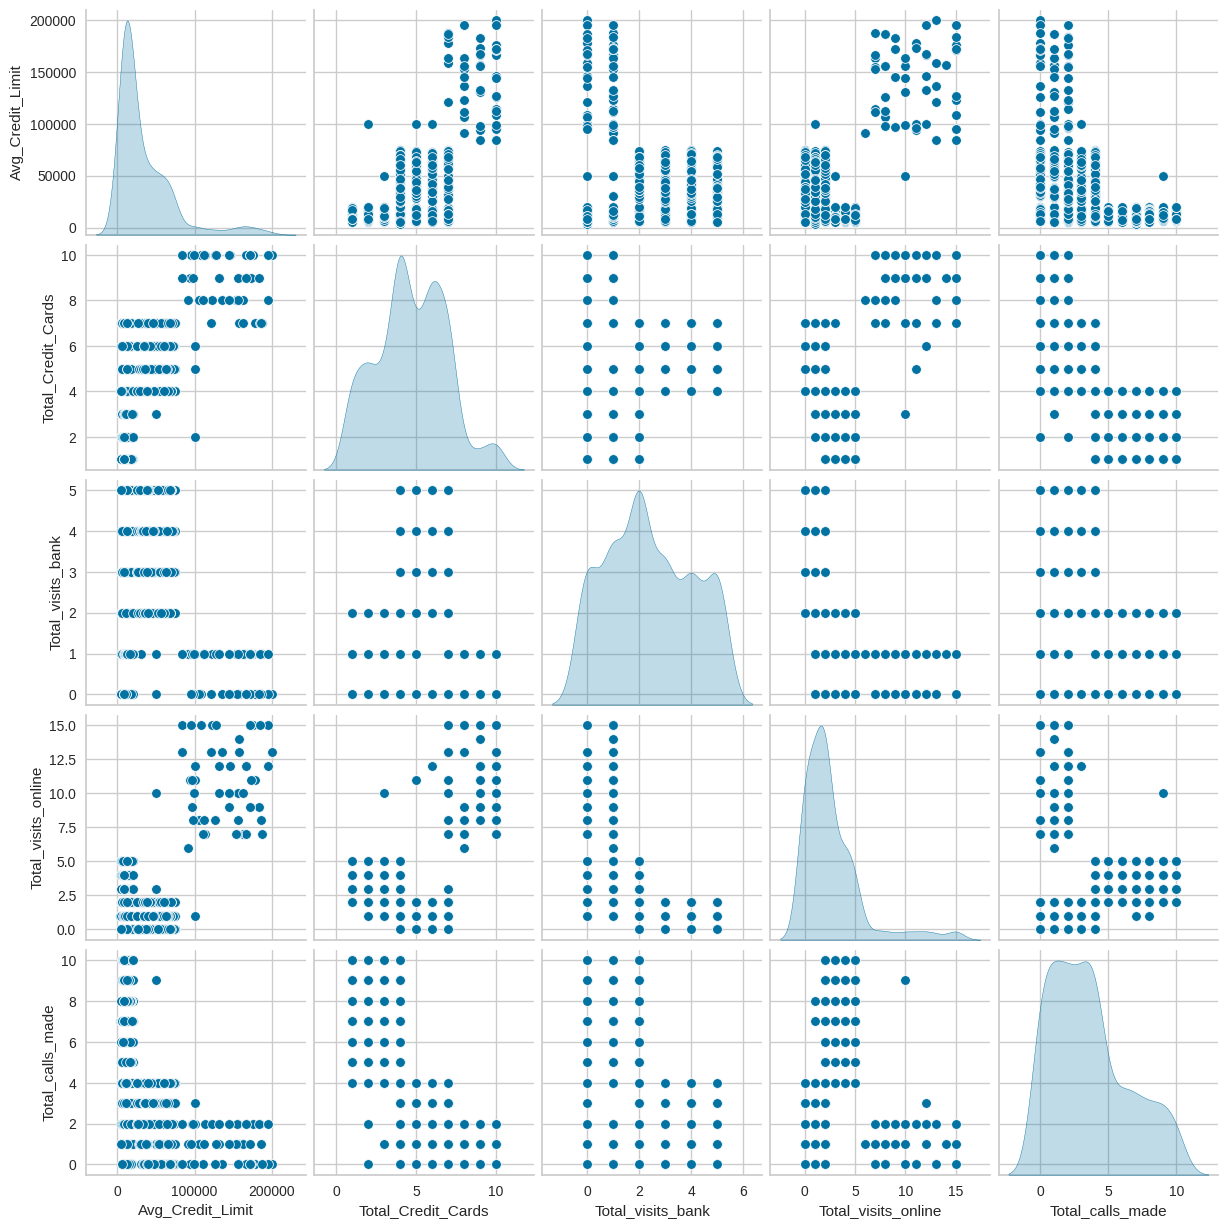

In [ ]:
sns.pairplot(df, diag_kind="kde")
plt.show()

Credit Limit vs Total Credit Cards

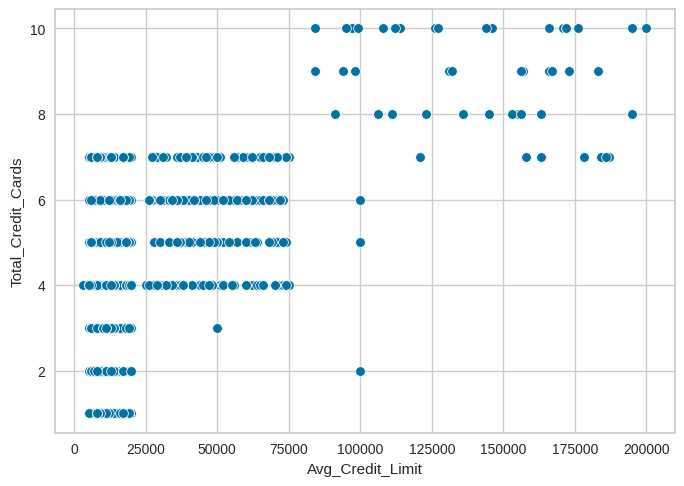

In [ ]:
sns.scatterplot(data=df, x="Avg_Credit_Limit", y="Total_Credit_Cards")
plt.show()

Online Visits vs Calls Made

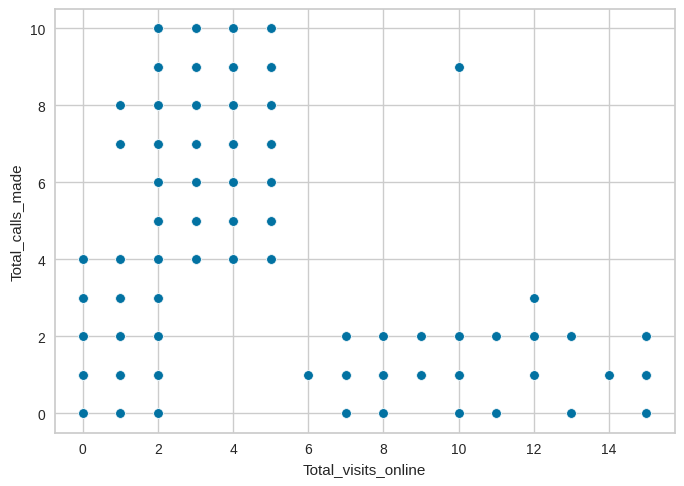

In [ ]:
sns.scatterplot(data=df, x="Total_visits_online", y="Total_calls_made")
plt.show()

Bank Visits vs Calls Made

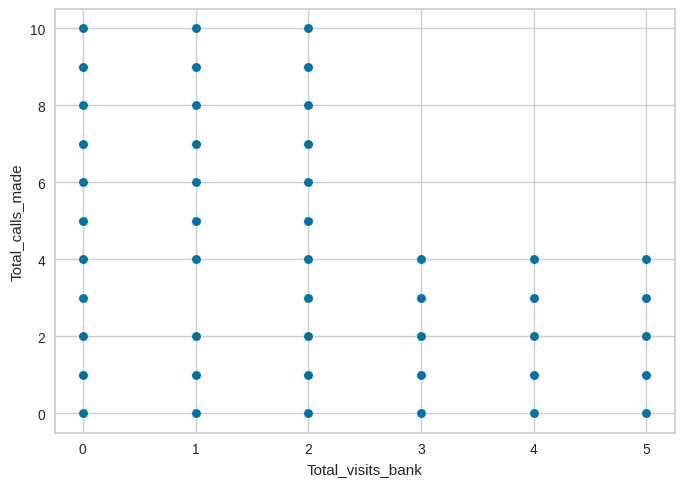

In [ ]:
sns.scatterplot(data=df, x="Total_visits_bank", y="Total_calls_made")
plt.show()

## Data Preprocessing

Missing Values

In [ ]:
data.isnull().sum()

,0
Sl_No,0
Customer Key,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0


Duplicate values

In [7]:
data.duplicated().sum()

np.int64(0)

statistical summary

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Sl_No,660.0,330.500000,190.669872,1.0,165.75,330.5,495.25,660.0
Customer Key,660.0,55141.443939,25627.772200,11265.0,33825.25,53874.5,77202.50,99843.0
Avg_Credit_Limit,660.0,34574.242424,37625.487804,3000.0,10000.00,18000.0,48000.00,200000.0
Total_Credit_Cards,660.0,4.706061,2.167835,1.0,3.00,5.0,6.00,10.0
Total_visits_bank,660.0,2.403030,1.631813,0.0,1.00,2.0,4.00,5.0
Total_visits_online,660.0,2.606061,2.935724,0.0,1.00,2.0,4.00,15.0
Total_calls_made,660.0,3.583333,2.865317,0.0,1.00,3.0,5.00,10.0


Outlier Check

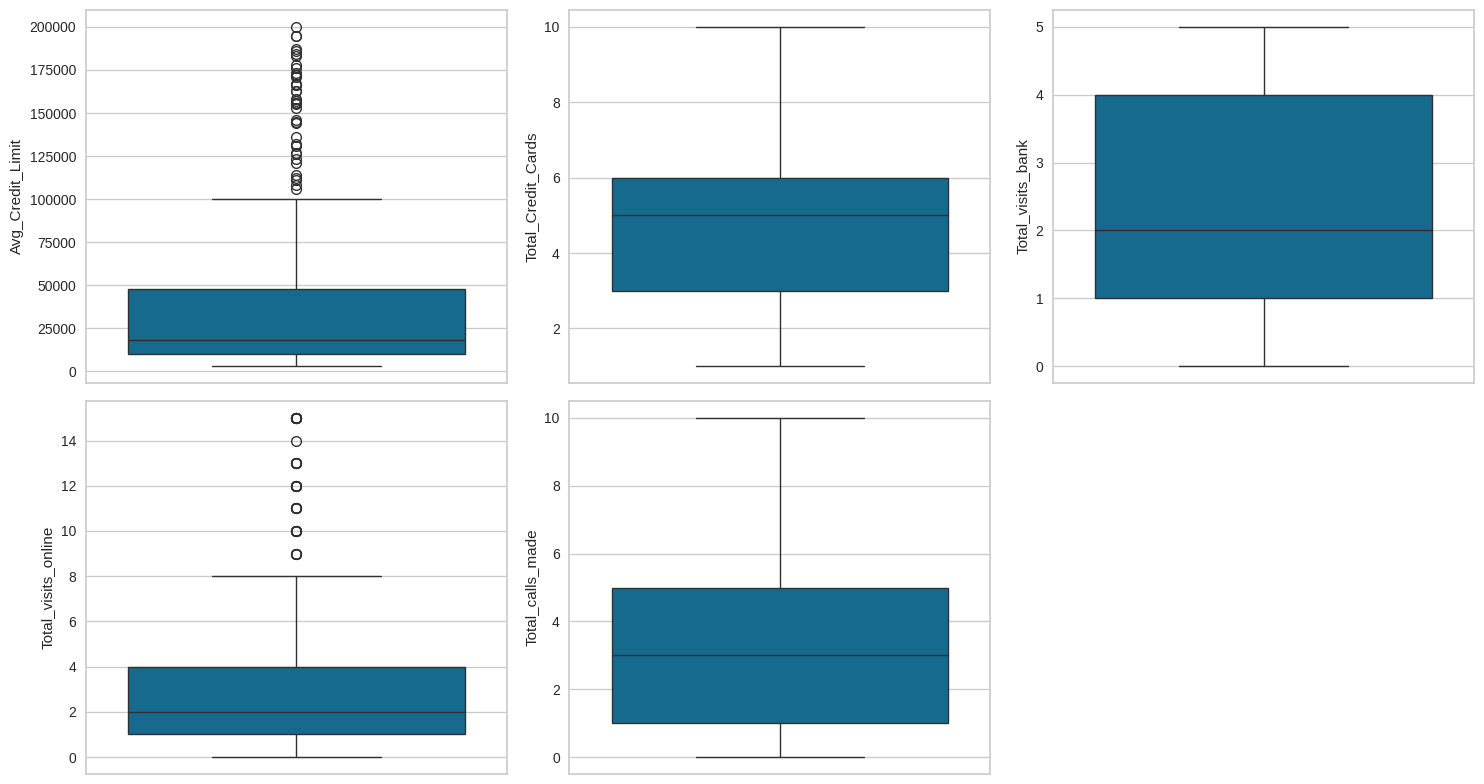

In [ ]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_col):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(data=df, y=col)
plt.tight_layout()
plt.show()

In [8]:
outlier_summary = []
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary.append({
        "Feature": col,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "No. of Outliers": outliers.shape[0],
        "Percentage of Outliers": round((outliers.shape[0] / df.shape[0]) * 100, 2)
    })
outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Feature,Lower Bound,Upper Bound,No. of Outliers,Percentage of Outliers
0,Avg_Credit_Limit,-47000.0,105000.0,39,5.91
1,Total_Credit_Cards,-1.5,10.5,0,0.00
2,Total_visits_bank,-3.5,8.5,0,0.00
3,Total_visits_online,-3.5,8.5,37,5.61
4,Total_calls_made,-5.0,11.0,0,0.00


Data Scaling

In [9]:
scaler = StandardScaler()
subset = df[num_col].copy()
subset_scaled = scaler.fit_transform(subset)
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

## K-means clustering

Apply

In [10]:
clusters = range(1, 10)
inertias = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=1)
    model.fit(subset_scaled_df)
    inertias.append(model.inertia_)
    print("k =", k, "  Inertia:", round(model.inertia_, 2))

k = 1   Inertia: 3300.0
k = 2   Inertia: 2138.63
k = 3   Inertia: 933.04
k = 4   Inertia: 854.25
k = 5   Inertia: 704.79
k = 6   Inertia: 654.19
k = 7   Inertia: 600.23
k = 8   Inertia: 595.92
k = 9   Inertia: 572.09


Elbow curve

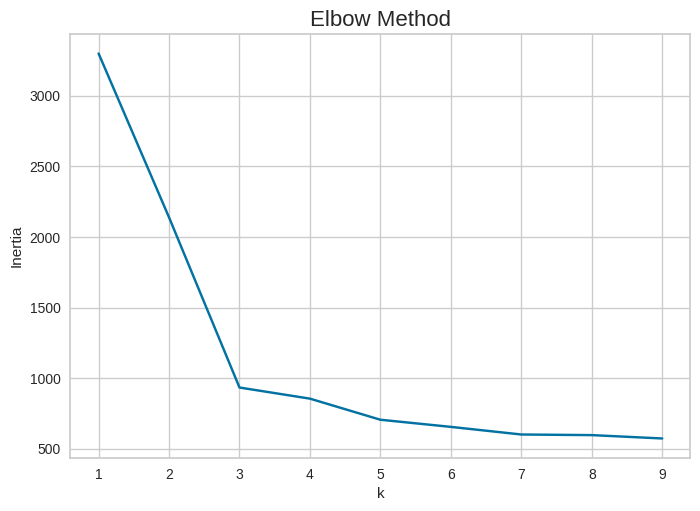

In [ ]:
plt.plot(clusters, inertias, "bx-")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method", fontsize=16)
plt.show()

Silhouette Scores

In [11]:
sil_scores = []
cluster_list = list(range(2, 10))

for k in cluster_list:
    model = KMeans(n_clusters=k, random_state=1)
    preds = model.fit_predict(subset_scaled_df)
    score = silhouette_score(subset_scaled_df, preds)
    sil_scores.append(score)
    print("k =", k, "  Silhouette Score:", round(score, 4))

k = 2   Silhouette Score: 0.5703
k = 3   Silhouette Score: 0.5157
k = 4   Silhouette Score: 0.3744
k = 5   Silhouette Score: 0.2717
k = 6   Silhouette Score: 0.248
k = 7   Silhouette Score: 0.2479
k = 8   Silhouette Score: 0.2257
k = 9   Silhouette Score: 0.1993


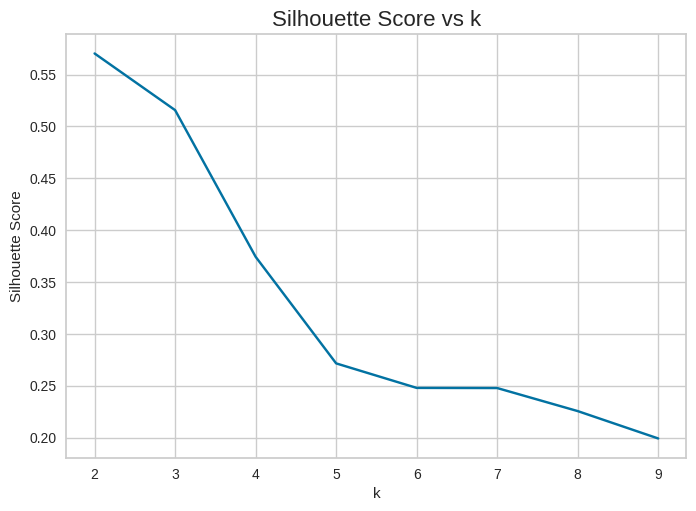

In [ ]:
plt.plot(cluster_list, sil_scores, "bx-")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k", fontsize=16)
plt.show()

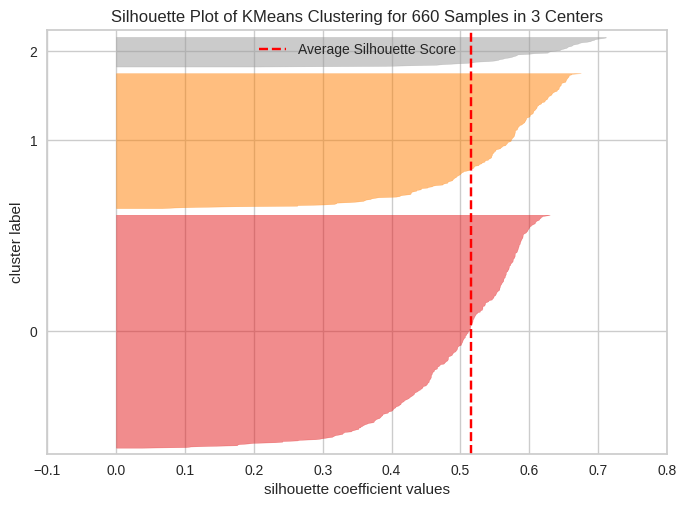

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
visualizer = SilhouetteVisualizer(KMeans(3, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

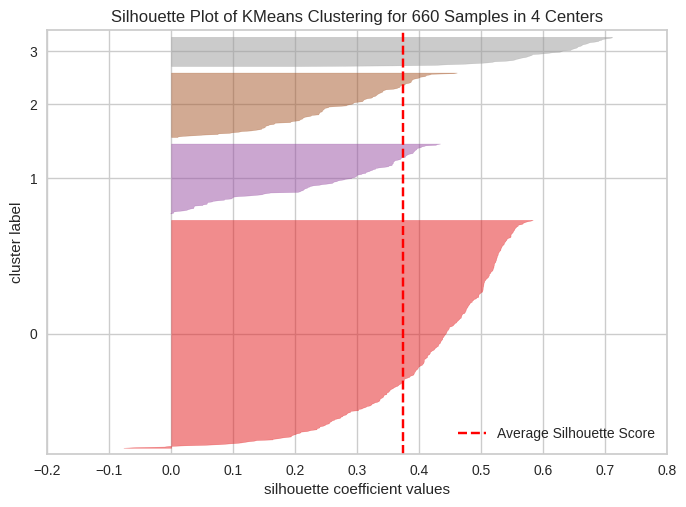

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
visualizer = SilhouetteVisualizer(KMeans(4, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

Final K-Means model with appropriate number of clusters

In [12]:
kmeans_model = KMeans(n_clusters=3, random_state=1)
kmeans_model.fit(subset_scaled_df)
df["KMeans_Clusters"] = kmeans_model.labels_

K-Means Cluster Profiling

In [13]:
km_profile = df.groupby("KMeans_Clusters").mean()
km_profile["count"] = df.groupby("KMeans_Clusters")["Avg_Credit_Limit"].count().values
km_profile.style.highlight_max(color="lightgreen", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count
KMeans_Clusters,,,,,,
0,33782.383420,5.515544,3.489637,0.981865,2.000000,386
1,12174.107143,2.410714,0.933036,3.553571,6.870536,224
2,141040.000000,8.740000,0.600000,10.900000,1.080000,50


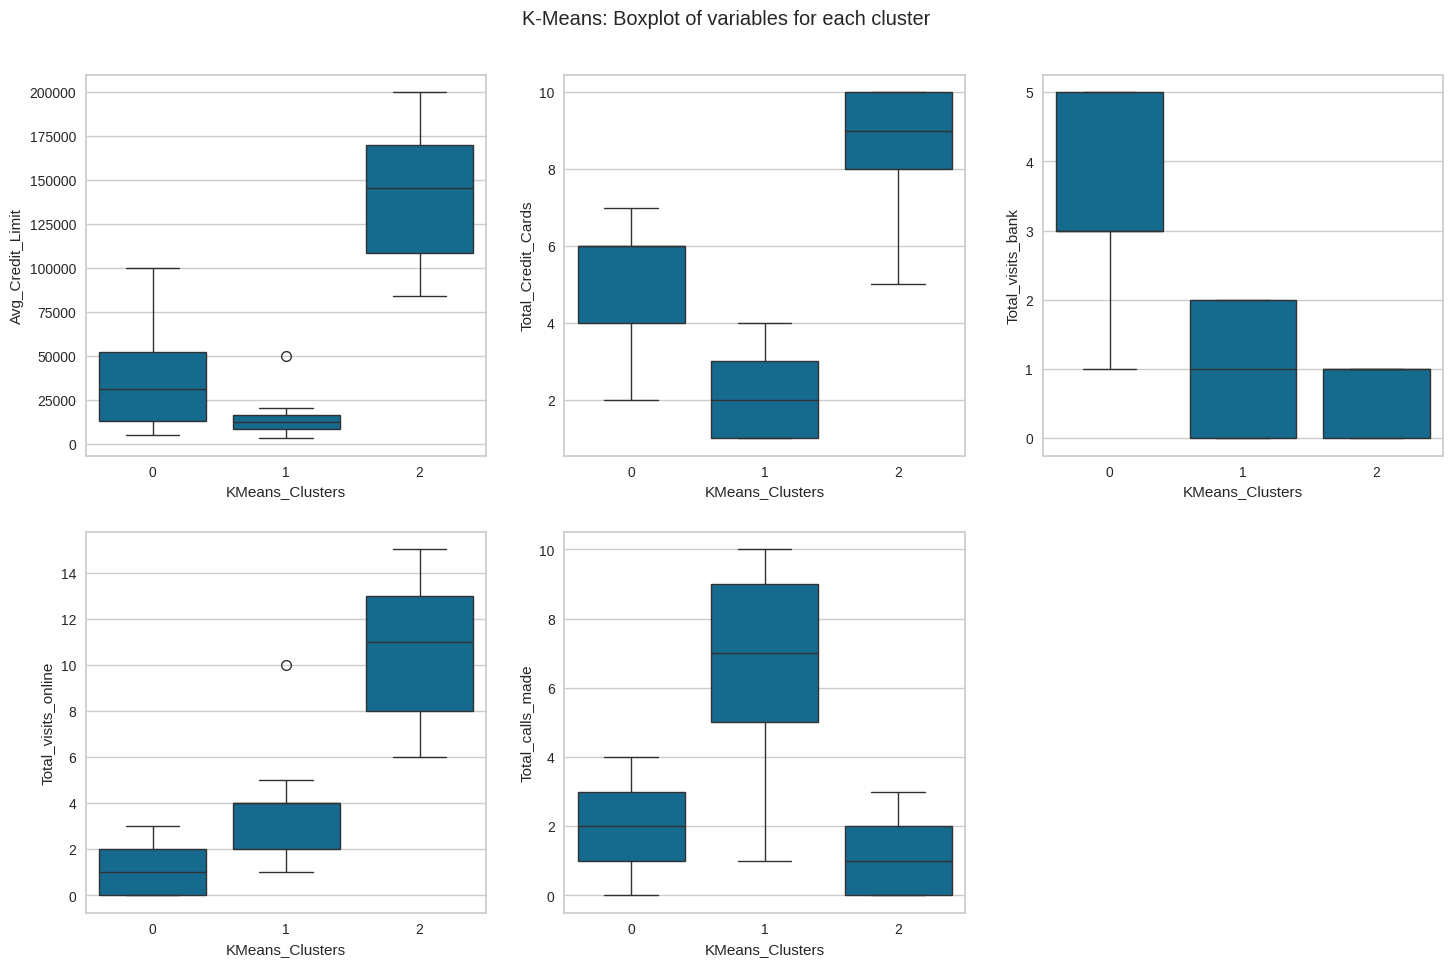

In [14]:
plt.figure(figsize=(15, 10))
plt.suptitle("K-Means: Boxplot of variables for each cluster")
for i, col in enumerate(num_col):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(data=df, x="KMeans_Clusters", y=col)
plt.tight_layout(pad=2.0)
plt.show()

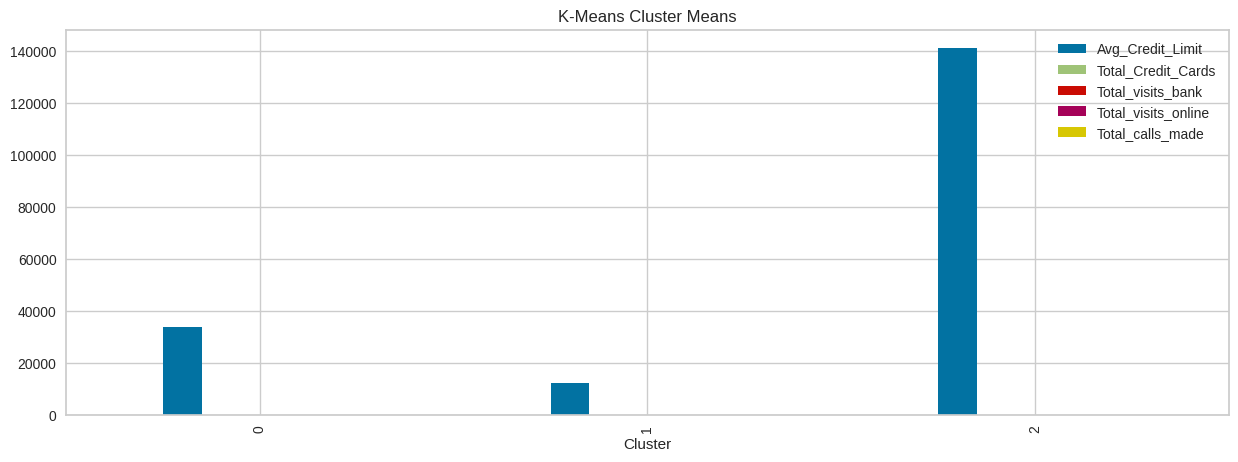

In [15]:
df.drop("KMeans_Clusters", axis=1).assign(Cluster=df["KMeans_Clusters"])\
  .groupby("Cluster")[num_col].mean().plot.bar(figsize=(15, 5))
plt.title("K-Means Cluster Means")
plt.show()

## Hierarchical Clustering

Cophenetic correlation (different methods)

In [16]:
Z1 = linkage(subset_scaled_df, metric="euclidean", method="ward")
c1, _ = cophenet(Z1, pdist(subset_scaled_df))
print("euclidean + ward:", round(c1, 4))

Z2 = linkage(subset_scaled_df, metric="euclidean", method="average")
c2, _ = cophenet(Z2, pdist(subset_scaled_df))
print("euclidean + average:", round(c2, 4))

Z3 = linkage(subset_scaled_df, metric="euclidean", method="complete")
c3, _ = cophenet(Z3, pdist(subset_scaled_df))
print("euclidean + complete:", round(c3, 4))

Z4 = linkage(subset_scaled_df, metric="cityblock", method="average")
c4, _ = cophenet(Z4, pdist(subset_scaled_df))
print("cityblock + average:", round(c4, 4))

Z5 = linkage(subset_scaled_df, metric="cityblock", method="complete")
c5, _ = cophenet(Z5, pdist(subset_scaled_df))
print("cityblock + complete:", round(c5, 4))

euclidean + ward: 0.7415
euclidean + average: 0.8977
euclidean + complete: 0.86
cityblock + average: 0.8963
cityblock + complete: 0.8731


Dendograms

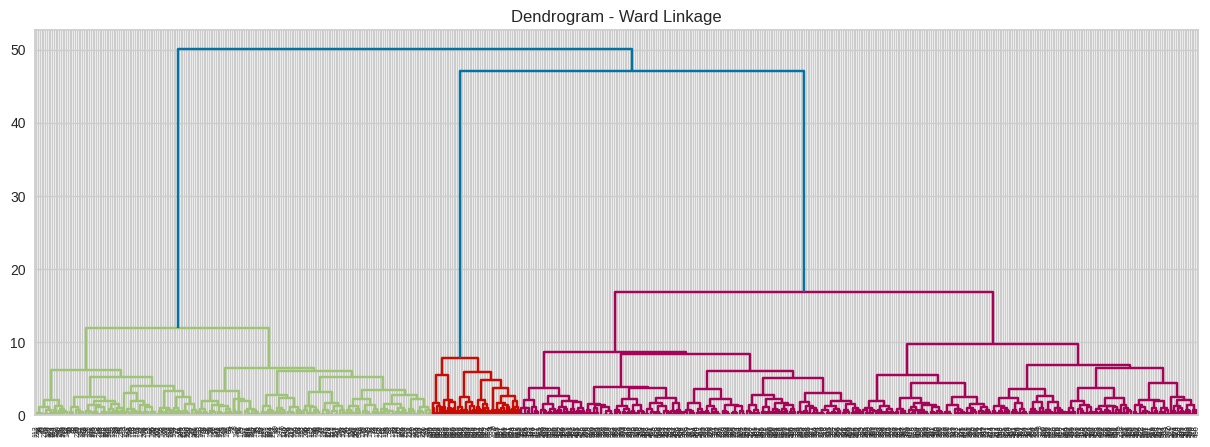

In [17]:
plt.figure(figsize=(15, 5))
Z = linkage(subset_scaled_df, metric="euclidean", method="ward")
dendrogram(Z)
plt.title("Dendrogram - Ward Linkage")
plt.show()

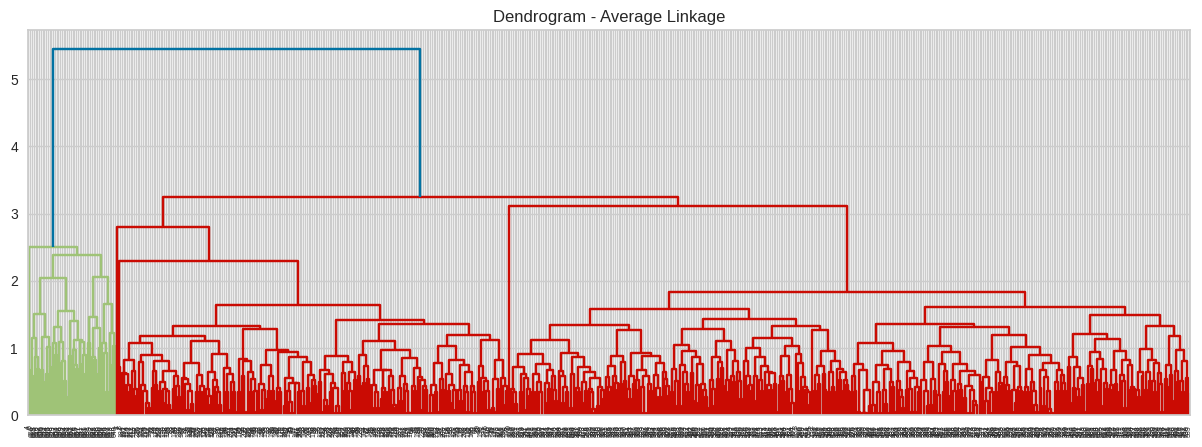

In [18]:
plt.figure(figsize=(15, 5))
Z = linkage(subset_scaled_df, metric="euclidean", method="average")
dendrogram(Z)
plt.title("Dendrogram - Average Linkage")
plt.show()

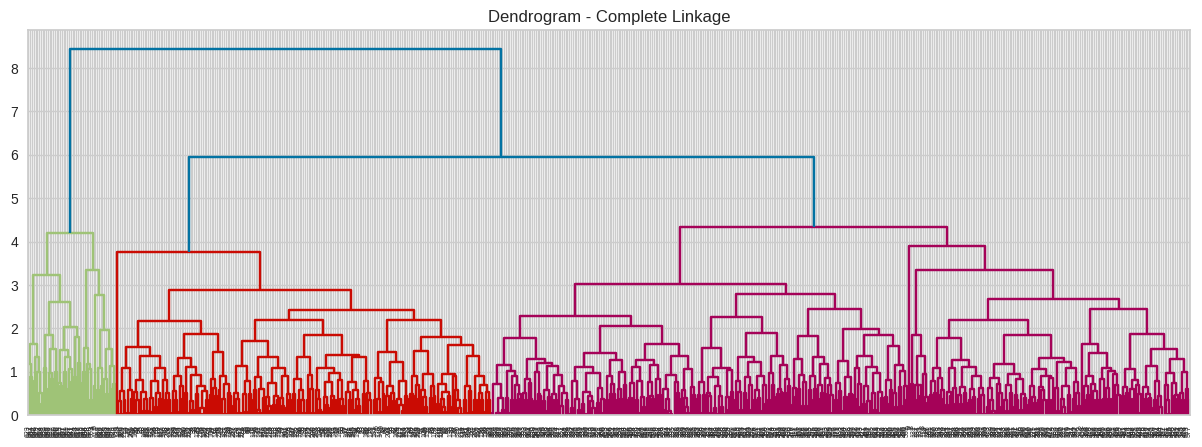

In [19]:
plt.figure(figsize=(15, 5))
Z = linkage(subset_scaled_df, metric="euclidean", method="complete")
dendrogram(Z)
plt.title("Dendrogram - Complete Linkage")
plt.show()

Silhouette Score

k = 2 Silhouette Score: 0.4177
k = 3 Silhouette Score: 0.5148
k = 4 Silhouette Score: 0.3481
k = 5 Silhouette Score: 0.2569
k = 6 Silhouette Score: 0.2268
k = 7 Silhouette Score: 0.2163


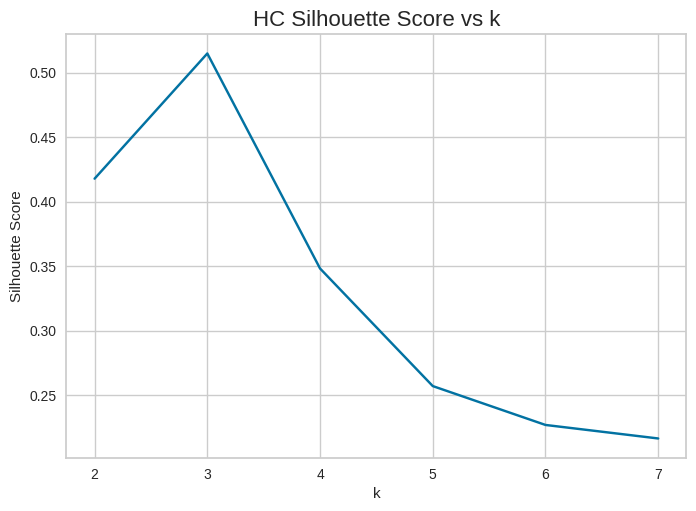

In [21]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

hc_sil_scores = []
cluster_list = list(range(2, 8))

for k in cluster_list:
    hc = AgglomerativeClustering(n_clusters=k, metric="euclidean", linkage="ward")
    preds = hc.fit_predict(subset_scaled_df)
    score = silhouette_score(subset_scaled_df, preds)
    hc_sil_scores.append(score)
    print("k =", k, "Silhouette Score:", round(score, 4))

plt.plot(cluster_list, hc_sil_scores, "bx-")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("HC Silhouette Score vs k", fontsize=16)
plt.show()

Final Hierarchical Model

In [31]:
hc = AgglomerativeClustering(n_clusters=3, linkage='average')
df["HC_Clusters"] = hc_model.fit_predict(subset_scaled_df)

Hierarchical Cluster Profiling

In [32]:
hc_profile = df.groupby("HC_Clusters").mean()
hc_profile["count"] = df.groupby("HC_Clusters")["Avg_Credit_Limit"].count().values
hc_profile.style.highlight_max(color="lightgreen", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,KMeans_Clusters,count
HC_Clusters,,,,,,,
0,33713.178295,5.511628,3.485788,0.984496,2.005168,0.002584,387
1,141040.000000,8.740000,0.600000,10.900000,1.080000,2.000000,50
2,12197.309417,2.403587,0.928251,3.560538,6.883408,1.000000,223


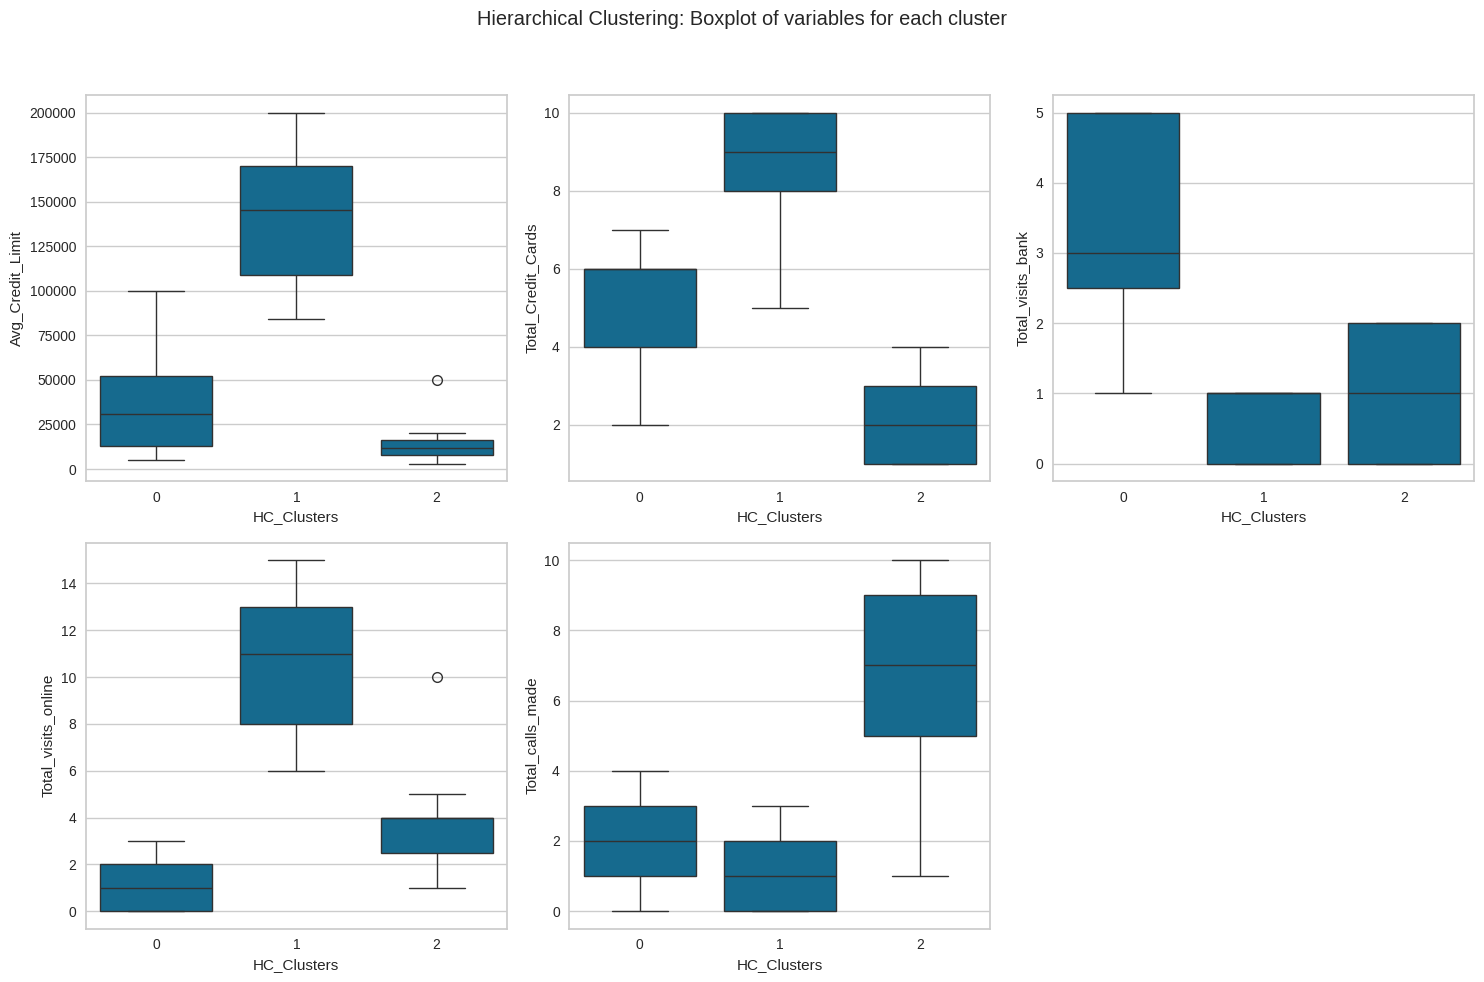

In [34]:
plt.figure(figsize=(15, 10))
plt.suptitle("Hierarchical Clustering: Boxplot of variables for each cluster")

for i, col in enumerate(num_col):
    plt.subplot(2, 3, i+1)
    sns.boxplot(data=df, x="HC_Clusters", y=col)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

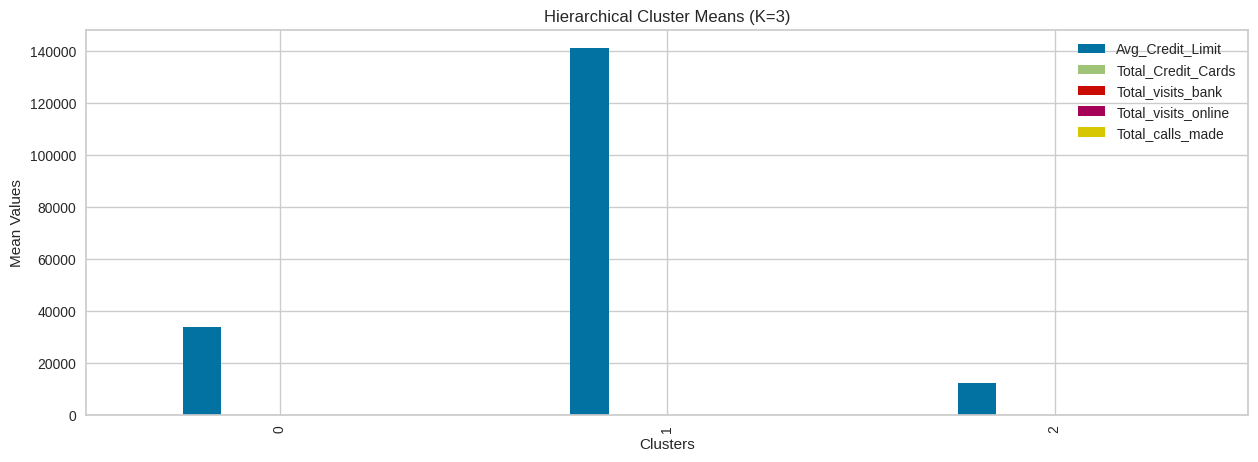

In [35]:
df.groupby("HC_Clusters")[num_col].mean().plot(kind='bar', figsize=(15,5))
plt.title("Hierarchical Cluster Means (K=3)")
plt.xlabel("Clusters")
plt.ylabel("Mean Values")
plt.show()

K-Means vs Hierarchical Clustering comparison

In [36]:
print("K-Means cluster sizes:")
print(df["KMeans_Clusters"].value_counts())

print("\nHierarchical cluster sizes:")
print(df["HC_Clusters"].value_counts())

K-Means cluster sizes:
KMeans_Clusters
0    386
1    224
2     50
Name: count, dtype: int64

Hierarchical cluster sizes:
HC_Clusters
0    387
2    223
1     50
Name: count, dtype: int64


In [37]:
print("K-Means Cluster Means:")
print(df.groupby("KMeans_Clusters")[num_col].mean().round(2))

print("\nHierarchical Cluster Means:")
print(df.groupby("HC_Clusters")[num_col].mean().round(2))

K-Means Cluster Means:
                 Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
KMeans_Clusters                                                            
0                        33782.38                5.52               3.49   
1                        12174.11                2.41               0.93   
2                       141040.00                8.74               0.60   

                 Total_visits_online  Total_calls_made  
KMeans_Clusters                                         
0                               0.98              2.00  
1                               3.55              6.87  
2                              10.90              1.08  

Hierarchical Cluster Means:
             Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
HC_Clusters                                                            
0                    33713.18                5.51               3.49   
1                   141040.00                8.74               0.